<a href="https://colab.research.google.com/github/glasslego/ml-deep-learning-study/blob/main/src/deep_learning_basic/0_xor_problem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# XOR 문제와 비선형성의 이해

XOR(Exclusive OR) 문제는 딥러닝을 이해하는 데 매우 중요한 개념입니다. 이 문제를 통해 왜 신경망에 비선형 활성화 함수가 필요한지 알 수 있습니다.

<table align="left">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/glasslego/ml-deep-learning-study/blob/main/src/deep_learning_basic/0_xor_problem.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />구글 코랩에서 실행하기</a>
  </td>
</table>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import warnings
warnings.filterwarnings("ignore")

# 나눔고딕 폰트 설치
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

# 폰트 설정
plt.rc('font', family='NanumGothic')
plt.rc('axes', unicode_minus=False)  # 마이너스 기호 깨짐 방지

# PyTorch 및 환경 정보 출력
print(f"PyTorch 버전: {torch.__version__}")

# GPU 사용 가능 여부 확인 (Google Colab T4 환경)
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using device: {device}")
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA 버전: {torch.version.cuda}")
else:
    device = torch.device("cpu")
    print(f"Using device: {device}")

# 랜덤 시드 설정 (재현 가능한 결과를 위해)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.cuda.manual_seed_all(42)
np.random.seed(42)

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 38 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

## 1. XOR 데이터 생성 및 시각화

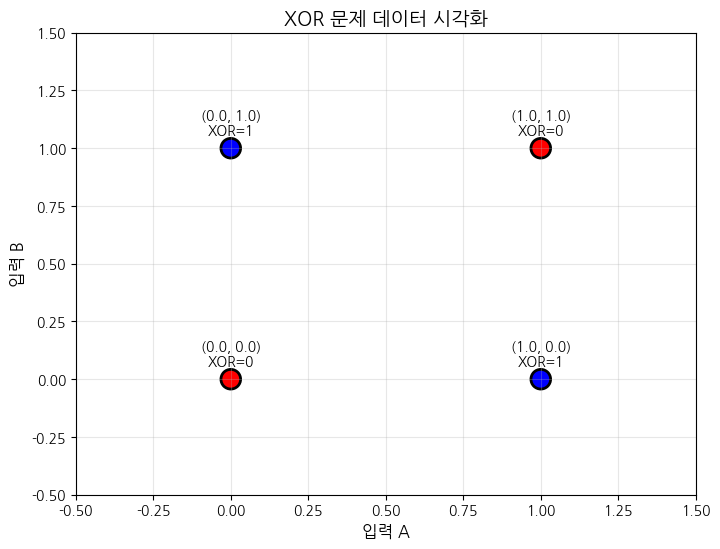

In [2]:
# XOR 데이터 생성
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=np.float32)
y = np.array([[0], [1], [1], [0]], dtype=np.float32)

# PyTorch 텐서로 변환
X_tensor = torch.from_numpy(X).to(device)
y_tensor = torch.from_numpy(y).to(device)

# 데이터 시각화
plt.figure(figsize=(8, 6))
colors = ['red' if label == 0 else 'blue' for label in y.flatten()]
plt.scatter(X[:, 0], X[:, 1], c=colors, s=200, edgecolors='black', linewidth=2)

# 각 점에 레이블 추가
for i, (x, y_val) in enumerate(zip(X, y)):
    plt.annotate(f'({x[0]}, {x[1]})\nXOR={int(y_val[0])}',
                 (x[0], x[1]),
                 textcoords="offset points",
                 xytext=(0,10),
                 ha='center')

plt.xlabel('입력 A', fontsize=12)
plt.ylabel('입력 B', fontsize=12)
plt.title('XOR 문제 데이터 시각화', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xlim(-0.5, 1.5)
plt.ylim(-0.5, 1.5)
plt.show()

## 2. 선형 모델로 XOR 문제 풀어보기 (실패하는 경우)

In [3]:
# 선형 모델 정의 (활성화 함수 없음)
class LinearModel(nn.Module):
    def __init__(self):
        super(LinearModel, self).__init__()
        self.linear = nn.Linear(2, 1)

    def forward(self, x):
        return torch.sigmoid(self.linear(x))  # sigmoid는 출력을 0과 1 사이로 만들기 위함

# 모델 생성 및 학습
linear_model = LinearModel().to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(linear_model.parameters(), lr=0.1)

# 학습
losses_linear = []
for epoch in range(1000):
    optimizer.zero_grad()
    outputs = linear_model(X_tensor)
    loss = criterion(outputs, y_tensor)
    loss.backward()
    optimizer.step()
    losses_linear.append(loss.item())

    if epoch % 200 == 0:
        print(f'Epoch {epoch}, Loss: {loss.item():.4f}')

# 예측 결과 출력
with torch.no_grad():
    predictions = linear_model(X_tensor)
    print("\n선형 모델 예측 결과:")
    for i, (input_val, pred, target) in enumerate(zip(X, predictions.cpu().numpy(), y)):
        print(f"입력: {input_val}, 예측: {pred[0]:.4f}, 실제: {target[0]}")

Epoch 0, Loss: 0.7317
Epoch 200, Loss: 0.6931
Epoch 400, Loss: 0.6931
Epoch 600, Loss: 0.6931
Epoch 800, Loss: 0.6931

선형 모델 예측 결과:
입력: [0. 0.], 예측: 0.5000, 실제: 0.0
입력: [0. 1.], 예측: 0.5000, 실제: 1.0
입력: [1. 0.], 예측: 0.5000, 실제: 1.0
입력: [1. 1.], 예측: 0.5000, 실제: 0.0


## 3. 선형 모델이 학습한 결정 경계 시각화

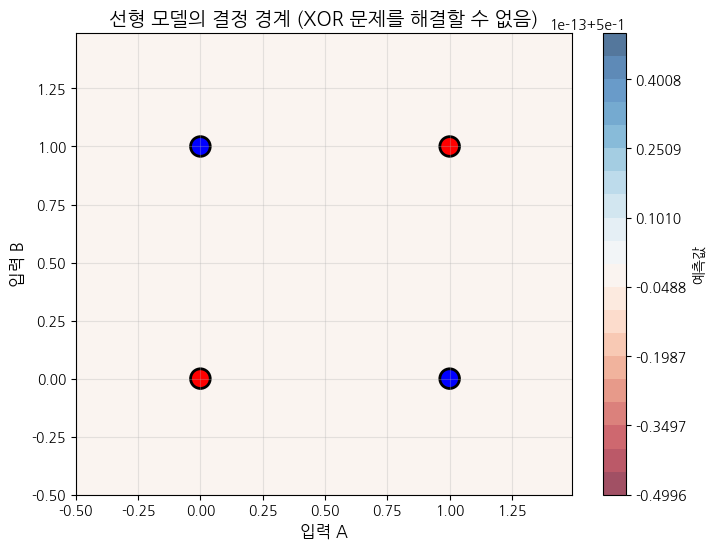

In [4]:
# 결정 경계 시각화 함수
def plot_decision_boundary(model, X, y, title):
    h = 0.01
    x_min, x_max = -0.5, 1.5
    y_min, y_max = -0.5, 1.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    grid_points = np.c_[xx.ravel(), yy.ravel()]
    grid_tensor = torch.from_numpy(grid_points.astype(np.float32)).to(device)

    with torch.no_grad():
        Z = model(grid_tensor).cpu().numpy()
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, levels=20, cmap='RdBu', alpha=0.7)
    plt.colorbar(label='예측값')

    colors = ['red' if label == 0 else 'blue' for label in y.flatten()]
    plt.scatter(X[:, 0], X[:, 1], c=colors, s=200, edgecolors='black', linewidth=2)

    plt.xlabel('입력 A', fontsize=12)
    plt.ylabel('입력 B', fontsize=12)
    plt.title(title, fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.show()

plot_decision_boundary(linear_model, X, y, "선형 모델의 결정 경계 (XOR 문제를 해결할 수 없음)")

## 4. 비선형 모델로 XOR 문제 해결하기

In [5]:
# 비선형 모델 정의 (은닉층과 활성화 함수 포함)
class NonLinearModel(nn.Module):
    def __init__(self):
        super(NonLinearModel, self).__init__()
        self.hidden = nn.Linear(2, 4)  # 은닉층: 2개 입력 -> 4개 은닉 뉴런
        self.output = nn.Linear(4, 1)  # 출력층: 4개 은닉 뉴런 -> 1개 출력

    def forward(self, x):
        x = torch.relu(self.hidden(x))  # ReLU 활성화 함수 (비선형성)
        x = torch.sigmoid(self.output(x))  # 출력을 0과 1 사이로
        return x

# 모델 생성 및 학습
nonlinear_model = NonLinearModel().to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(nonlinear_model.parameters(), lr=0.1)

# 학습
losses_nonlinear = []
for epoch in range(1000):
    optimizer.zero_grad()
    outputs = nonlinear_model(X_tensor)
    loss = criterion(outputs, y_tensor)
    loss.backward()
    optimizer.step()
    losses_nonlinear.append(loss.item())

    if epoch % 200 == 0:
        print(f'Epoch {epoch}, Loss: {loss.item():.4f}')

# 예측 결과 출력
with torch.no_grad():
    predictions = nonlinear_model(X_tensor)
    print("\n비선형 모델 예측 결과:")
    for i, (input_val, pred, target) in enumerate(zip(X, predictions.cpu().numpy(), y)):
        print(f"입력: {input_val}, 예측: {pred[0]:.4f}, 실제: {target[0]}")

Epoch 0, Loss: 0.7057
Epoch 200, Loss: 0.0003
Epoch 400, Loss: 0.0001
Epoch 600, Loss: 0.0000
Epoch 800, Loss: 0.0000

비선형 모델 예측 결과:
입력: [0. 0.], 예측: 0.0000, 실제: 0.0
입력: [0. 1.], 예측: 1.0000, 실제: 1.0
입력: [1. 0.], 예측: 1.0000, 실제: 1.0
입력: [1. 1.], 예측: 0.0000, 실제: 0.0


## 5. 비선형 모델의 결정 경계 시각화

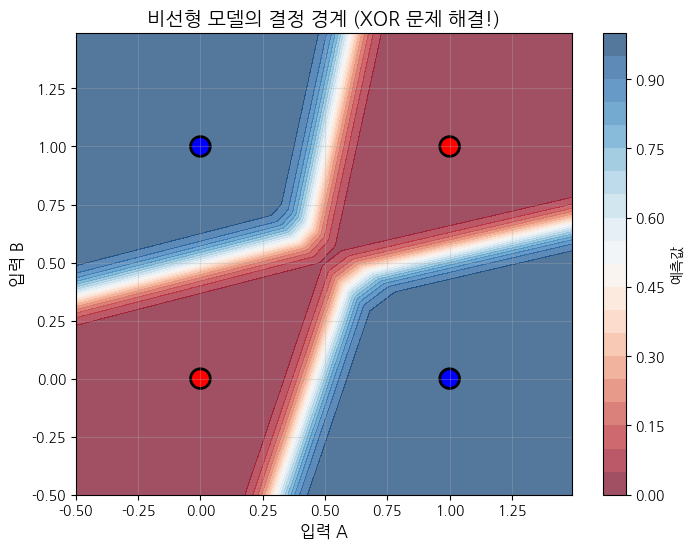

In [6]:
plot_decision_boundary(nonlinear_model, X, y, "비선형 모델의 결정 경계 (XOR 문제 해결!)")

## 6. 학습 과정 비교

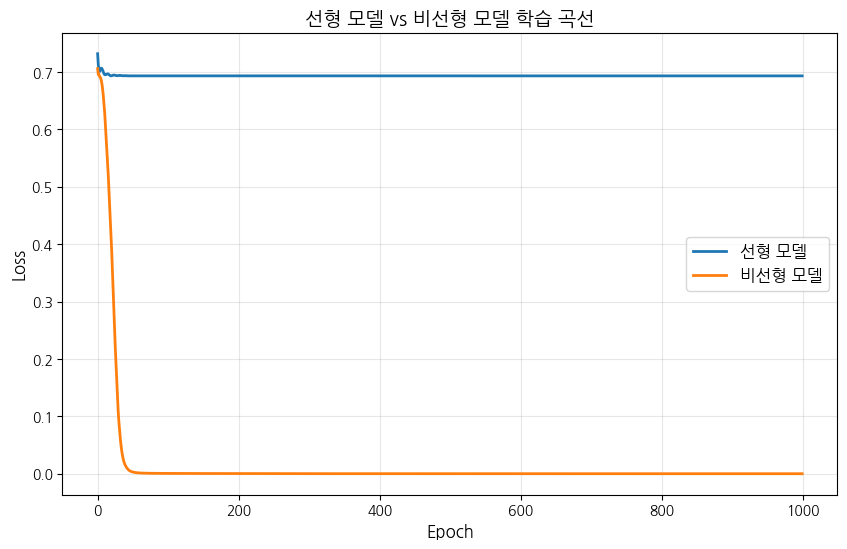

In [8]:
plt.figure(figsize=(10, 6))
plt.plot(losses_linear, label='선형 모델', linewidth=2)
plt.plot(losses_nonlinear, label='비선형 모델', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('선형 모델 vs 비선형 모델 학습 곡선', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

## 왜 선형 모델은 XOR 문제를 풀 수 없을까?

### 1. 선형 분리 불가능성
- XOR 문제의 데이터 포인트들은 하나의 직선으로 분리할 수 없습니다.
- (0,0)과 (1,1)은 같은 클래스(0)이고, (0,1)과 (1,0)은 다른 클래스(1)입니다.
- 어떤 직선을 그어도 이 네 점을 올바르게 분류할 수 없습니다.

### 2. 수학적 설명
선형 모델은 다음과 같은 형태입니다:
$$y = w_1 \cdot x_1 + w_2 \cdot x_2 + b$$

이는 2차원 평면에서 직선을 나타냅니다. XOR의 경우:
- (0,0) → 0
- (0,1) → 1  
- (1,0) → 1
- (1,1) → 0

이 조건들을 모두 만족하는 선형 방정식은 존재하지 않습니다.

### 3. 비선형성의 필요성
- 은닉층과 비선형 활성화 함수(ReLU, Sigmoid 등)를 추가하면 복잡한 결정 경계를 만들 수 있습니다.
- 이를 통해 XOR과 같은 비선형 문제를 해결할 수 있습니다.
- 이것이 딥러닝에서 활성화 함수가 필수적인 이유입니다!

## 7. 다양한 활성화 함수 비교

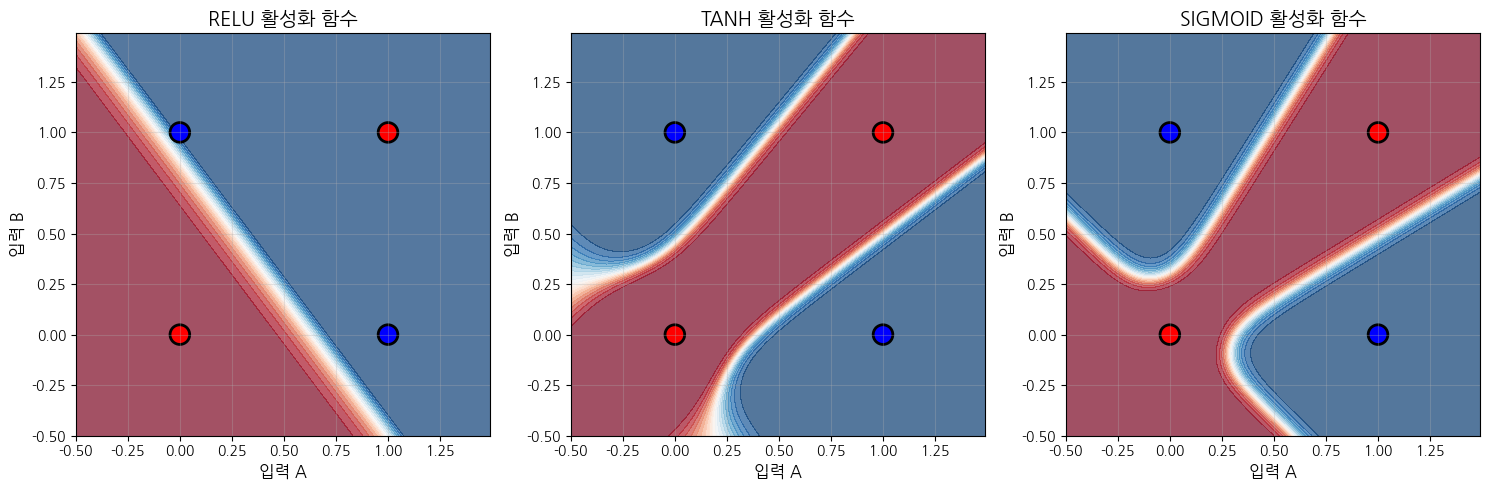

In [9]:
# 다양한 활성화 함수를 가진 모델 비교
class FlexibleModel(nn.Module):
    def __init__(self, activation='relu'):
        super(FlexibleModel, self).__init__()
        self.hidden = nn.Linear(2, 4)
        self.output = nn.Linear(4, 1)

        if activation == 'relu':
            self.activation = torch.relu
        elif activation == 'tanh':
            self.activation = torch.tanh
        elif activation == 'sigmoid':
            self.activation = torch.sigmoid

    def forward(self, x):
        x = self.activation(self.hidden(x))
        x = torch.sigmoid(self.output(x))
        return x

# 각 활성화 함수로 모델 학습
activations = ['relu', 'tanh', 'sigmoid']
models = {}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, activation in enumerate(activations):
    model = FlexibleModel(activation=activation).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.1)

    # 학습
    for epoch in range(1000):
        optimizer.zero_grad()
        outputs = model(X_tensor)
        loss = criterion(outputs, y_tensor)
        loss.backward()
        optimizer.step()

    models[activation] = model

    # 결정 경계 그리기
    h = 0.01
    x_min, x_max = -0.5, 1.5
    y_min, y_max = -0.5, 1.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    grid_points = np.c_[xx.ravel(), yy.ravel()]
    grid_tensor = torch.from_numpy(grid_points.astype(np.float32)).to(device)

    with torch.no_grad():
        Z = model(grid_tensor).cpu().numpy()
    Z = Z.reshape(xx.shape)

    ax = axes[idx]
    contour = ax.contourf(xx, yy, Z, levels=20, cmap='RdBu', alpha=0.7)

    colors = ['red' if label == 0 else 'blue' for label in y.flatten()]
    ax.scatter(X[:, 0], X[:, 1], c=colors, s=200, edgecolors='black', linewidth=2)

    ax.set_xlabel('입력 A', fontsize=12)
    ax.set_ylabel('입력 B', fontsize=12)
    ax.set_title(f'{activation.upper()} 활성화 함수', fontsize=14)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 결론

1. **XOR 문제는 선형적으로 분리할 수 없는 대표적인 문제입니다.**
2. **선형 모델(직선)로는 XOR 문제를 해결할 수 없습니다.**
3. **은닉층과 비선형 활성화 함수를 추가하면 복잡한 결정 경계를 만들어 XOR 문제를 해결할 수 있습니다.**
4. **이것이 딥러닝에서 다층 신경망과 활성화 함수가 필수적인 이유입니다!**

XOR 문제는 간단해 보이지만, 딥러닝의 핵심 개념인 비선형성의 중요성을 보여주는 완벽한 예제입니다.